### Pre-modeling

In [39]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('../data/processed/Telco-Customer-Churn-Processed.csv')

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=86, stratify=y
)

---

We have to choose which metric to use.

In our business problem:
- if model makes type 1 error -> company will trigger its standard retention protocols (discounts, sending gifts etc.) basically unnecessary costs

- if model makes type 2 error -> customer will leave, which will decrease revenue of the company, it also leads to damage to reputation and to spend more money on marketing

In [5]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

We see that dataset is imbalanced, so accuracy can't be used there.

Precision is also not the best option because cost of false positive is not that bad.

Cost of false negative on the other side is too high, so the best option is `recall` or `f1`, but i would stick up to recall, since FN is more dangerous and `threshold` in our case would be `0.3`

---

### Model selection (RF vs LGBM vs XGB)

In [6]:
# Robust to class imbalance 
ratio = (y_train == 0).sum() / (y_train == 1).sum()
THRESHOLD = 0.3

#### Random Forest 

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',
    random_state=75,
    n_jobs=-1
)

rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.50      0.66      1035
           1       0.41      0.95      0.57       374

    accuracy                           0.62      1409
   macro avg       0.69      0.73      0.62      1409
weighted avg       0.82      0.62      0.64      1409



Based on classification report we see, that model found 95% of churn customers

But on the other side it predicts only 41% of them correctly -> Model's making a lot of type 1 error    

---

#### LGBM

In [8]:
from lightgbm import LGBMClassifier

In [9]:
lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',
    random_state=75,
    n_jobs=-1
)

start = time.perf_counter()

lgbm.fit(X_train, y_train)

proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

end = time.perf_counter()

print(f"Training took {end - start:.3f} seconds")

print(classification_report(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Model caught 83% of actual churn customers (13% worse than baseline) -> which is overall not that bad, but model makes a lot of false positive mistakes (only 50% of predicted churns are actually churns) 

---

#### XGBoost

In [10]:
from xgboost import XGBClassifier

In [11]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',
    random_state=75,
    n_jobs=-1
)

start = time.perf_counter()

xgb.fit(X_train, y_train)

proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

end = time.perf_counter()

print(f"Training took {end - start:.3f} seconds")
print(classification_report(y_test, y_pred))

d:\reps\churn-customer\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:16:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training took 1.763 seconds
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1035
           1       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.73      1409
weighted avg       0.79      0.78      0.79      1409



XGBoost has slightly better accuracy, precision and it's 38% faster than LGBM

But on the recall metric it managed to find only 67% of all churns (16% worse)

---

I'm gonna choose LGBM since it managed to find more churn customers which for company is more significant since FN cost is very high, but not FP

Yes, i know that i'm gonna sacrifice speed and overall accuracy, but what this'll cost to company? Additional 10$ discount offer instead of customer leaving

In real world i'd decide what to sacrifice with company but since it's pet project i'm choosing `LGBM`

---

### Threshold testing

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_test)[:, 1]

for t in [0.2, 0.25, 0.3, 0.35, 0.4]:
    preds = (proba >= t).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"Threshold: {t} has precision: {prec:.3f}, recall: {rec:.3f}, f1: {f1:.3f}")

Threshold: 0.2 has precision: 0.449, recall: 0.885, f1: 0.595
Threshold: 0.25 has precision: 0.473, recall: 0.853, f1: 0.609
Threshold: 0.3 has precision: 0.498, recall: 0.826, f1: 0.622
Threshold: 0.35 has precision: 0.516, recall: 0.799, f1: 0.627
Threshold: 0.4 has precision: 0.538, recall: 0.783, f1: 0.638


Best precision-recall tradeoff found on 0.25 threshold, so i'll use it

In [13]:
THRESHOLD = 0.25

---

### Hyperparameters tuning

In [54]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [55]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=89
)

In [56]:
def objective(trial):
    params = {
        "n_estimators":trial.suggest_int("n_estimators", 300, 1500),
        "learning_rate":trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "max_depth":trial.suggest_int("max_depth", 3, 10),
        "num_leaves":trial.suggest_int("num_leaves", 16, 128),
        "subsample":trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples":trial.suggest_int("min_child_samples", 10, 100),
        "min_split_gain":trial.suggest_float("min_split_gain", 0.0, 1.0),
        "min_child_weight":trial.suggest_float("min_child_weight", 1e-3, 10, log=True),

        "reg_lambda":trial.suggest_float("reg_lambda", 1e-3, 20, log=True),
        "reg_alpha":trial.suggest_float("reg_alpha", 1e-3, 20, log=True),

        "subsample_freq":1,
        "scale_pos_weight":(y_train == 0).sum() / (y_train == 1).sum(),
        "random_state":87,
        "n_jobs":-1,
        "eval_metric":"auc",
        "objective":"binary",
        "verbosity":-1
    }

    model = LGBMClassifier(
        **params
    )

    model.fit(X_train, y_train)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1
    ).mean()

    return scores

In [57]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-07-20 18:02:10,648] A new study created in memory with name: no-name-13e2c26f-772e-4e43-9062-caf53b5e85fc
[I 2026-07-20 18:02:30,200] Trial 0 finished with value: 0.8094494787792584 and parameters: {'n_estimators': 1132, 'learning_rate': 0.1894220289810492, 'max_depth': 8, 'num_leaves': 97, 'subsample': 0.8749395193812274, 'colsample_bytree': 0.6835121215110889, 'min_child_samples': 31, 'min_split_gain': 0.42214011480058733, 'min_child_weight': 0.0029141976830689424, 'reg_lambda': 0.006985488209168517, 'reg_alpha': 0.05026401597757052}. Best is trial 0 with value: 0.8094494787792584.
[I 2026-07-20 18:02:42,078] Trial 1 finished with value: 0.8447194456063943 and parameters: {'n_estimators': 1434, 'learning_rate': 0.11775681180075122, 'max_depth': 3, 'num_leaves': 106, 'subsample': 0.9322369175592919, 'colsample_bytree': 0.7199790473935817, 'min_child_samples': 82, 'min_split_gain': 0.15296676695663114, 'min_child_weight': 0.9816810184585028, 'reg_lambda': 0.011792869277064051, 

---

### Best model & Evaluation

In [58]:
best_params = study.best_params

print(f"Best params: {study.best_params}")
print(f"Best score: {study.best_value}")

Best params: {'n_estimators': 1475, 'learning_rate': 0.004066634546731806, 'max_depth': 4, 'num_leaves': 87, 'subsample': 0.7714032286196228, 'colsample_bytree': 0.9805207844724112, 'min_child_samples': 72, 'min_split_gain': 0.02590652994556636, 'min_child_weight': 3.089489798563455, 'reg_lambda': 0.08797465538237195, 'reg_alpha': 8.694749111974744}
Best score: 0.8449355673131798


In [59]:
best_model = LGBMClassifier(**best_params)
best_model.fit(X_train, y_train)

,num_leaves,87
,max_depth,4
,learning_rate,0.004066634546731806
,n_estimators,1475
,min_split_gain,0.02590652994556636
,min_child_weight,3.089489798563455
,min_child_samples,72
,subsample,0.7714032286196228
,colsample_bytree,0.9805207844724112
,reg_alpha,8.694749111974744
,reg_lambda,0.08797465538237195


#### Overfitting testing

In [60]:
train_prob = best_model.predict_proba(X_train)[:, 1]
train_pred = (train_prob >= THRESHOLD).astype(int)

test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= THRESHOLD).astype(int)

In [61]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, recall_score

print(f"Train Accuracy: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test Accuracy : {accuracy_score(y_test, test_pred):.3f}")

print("-" * 25)

print(f"Train F1: {f1_score(y_train, train_pred):.3f}")
print(f"Test F1 : {f1_score(y_test, test_pred):.3f}")

print("-" * 25)

print(f"Train ROC AUC: {roc_auc_score(y_train, train_prob):.3f}")
print(f"Test ROC AUC : {roc_auc_score(y_test, test_prob):.3f}")

print("-" * 25)

print(f"Train Recall: {recall_score(y_train, train_pred):.3f}")
print(f"Test Recall : {recall_score(y_test, test_pred):.3f}")

Train Accuracy: 0.750
Test Accuracy : 0.763
-------------------------
Train F1: 0.638
Test F1 : 0.655
-------------------------
Train ROC AUC: 0.862
Test ROC AUC : 0.861
-------------------------
Train Recall: 0.831
Test Recall : 0.848


The problem that i faced here is that i was applying default threshold (0.5) intead of custom one

Because of this most of my predictions has failed and i got both F1 scores 0.000, but it was quickly fixed by switching back to custom 0.25 threshold

---

I also tried to run optuna with CV and without it, here's results:

- Without it: params tuning lasts `30 seconds`

- With it: almost `6 minutes` and score on avg increased only by `1.33%` and actually decreased recall by `1.6%`

---

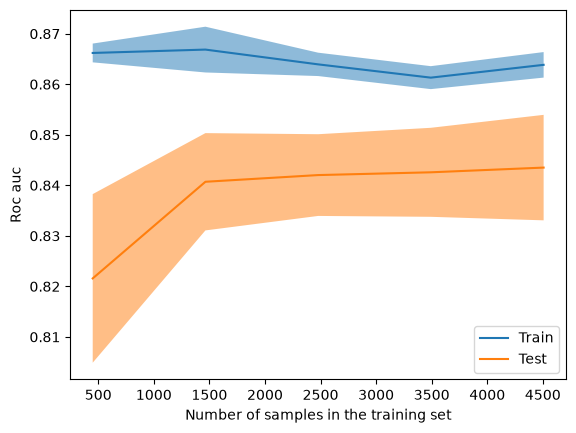

In [62]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

plt.show()

---